<a href="https://colab.research.google.com/github/jshs2707-star/earthquake-waveform-analyzer-/blob/main/%EC%A7%80%EA%B3%BC%EC%8B%A4%ED%97%98_%EA%B3%A0%EC%A7%80%EC%9E%90%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pmagpy scipy

In [ ]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmagpy import ipmag
from IPython.display import display

warnings.filterwarnings("ignore")

# ============================================================
# 설정
# ============================================================

MAGIC_ID = "20818"
MIN_POINTS = 5
TRAIN_RATIO = 0.70
N_WEIGHT_SEARCH = 300
SEED = 2026

DATA_DIR = "/content/chrm_data"
OUT_DIR = "/content/chrm_result"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

rng = np.random.default_rng(SEED)


# ============================================================
# 1. MagIC 데이터 다운로드
# ============================================================

measurement_path = os.path.join(DATA_DIR, "measurements.txt")

if not os.path.exists(measurement_path):
    print("MagIC 데이터 다운로드 중...")
    status, message = ipmag.download_magic_from_id(MAGIC_ID, directory=DATA_DIR)

    if not status:
        raise RuntimeError(message)

    files = glob.glob(os.path.join(DATA_DIR, "magic_contribution*.txt"))
    contribution_file = sorted(files, key=os.path.getmtime)[-1]

    ipmag.download_magic(
        infile=os.path.basename(contribution_file),
        input_dir_path=DATA_DIR,
        dir_path=DATA_DIR,
        overwrite=True
    )


def read_magic(filename):
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        return None
    return pd.read_csv(path, sep="\t", header=1, low_memory=False)


measurements = read_magic("measurements.txt")
specimens_table = read_magic("specimens.txt")

print("Measurements:", measurements.shape)


# ============================================================
# 2. 방향 ↔ Cartesian 벡터
# ============================================================

def dir2cart(dec, inc, mag=1.0):
    d = np.radians(np.asarray(dec, dtype=float))
    i = np.radians(np.asarray(inc, dtype=float))
    m = np.asarray(mag, dtype=float)

    x = m * np.cos(i) * np.cos(d)
    y = m * np.cos(i) * np.sin(d)
    z = m * np.sin(i)

    if np.ndim(x) == 0:
        return np.array([x, y, z])

    return np.column_stack([x, y, z])


def cart2dir(v):
    v = np.asarray(v, dtype=float)
    mag = np.linalg.norm(v)

    if mag == 0:
        return np.nan, np.nan

    dec = (np.degrees(np.arctan2(v[1], v[0])) + 360) % 360
    inc = np.degrees(np.arcsin(np.clip(v[2] / mag, -1, 1)))

    return dec, inc


def vector_angle(a, b, axis=False):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return np.nan

    value = np.clip(np.dot(a, b) / (na * nb), -1, 1)
    ang = np.degrees(np.arccos(value))

    if axis:
        ang = min(ang, 180 - ang)

    return ang


# ============================================================
# 3. 단계별 소자 데이터 추출
# ============================================================

def choose_mag_column(g):
    for col in ["magn_moment", "magn_volume", "magn_mass"]:
        if col in g.columns:
            n = pd.to_numeric(g[col], errors="coerce").notna().sum()
            if n >= MIN_POINTS:
                return col
    return None


def build_sequence(g, demag_type):
    g = g.copy()

    if "quality" in g.columns:
        g = g[g["quality"].fillna("g").astype(str).str.lower() != "b"]

    methods = g["method_codes"].fillna("").astype(str)

    if demag_type == "AF":
        if "treat_ac_field" not in g.columns:
            return None
        q = g[methods.str.contains("LT-AF-Z|LT-NO", regex=True)].copy()
        unit = "mT"
    else:
        if "treat_temp" not in g.columns:
            return None
        q = g[methods.str.contains("LT-T-Z|LT-NO", regex=True)].copy()
        unit = "°C"

    if len(q) < MIN_POINTS:
        return None

    mag_col = choose_mag_column(q)
    if mag_col is None:
        return None

    q["dec"] = pd.to_numeric(q["dir_dec"], errors="coerce")
    q["inc"] = pd.to_numeric(q["dir_inc"], errors="coerce")
    q["mag"] = pd.to_numeric(q[mag_col], errors="coerce")

    is_nrm = q["method_codes"].fillna("").astype(str).str.contains("LT-NO", regex=False)

    if demag_type == "AF":
        raw = pd.to_numeric(q["treat_ac_field"], errors="coerce")
        q["step"] = np.where(is_nrm, 0, raw * 1000)
    else:
        raw = pd.to_numeric(q["treat_temp"], errors="coerce")
        q["step"] = np.where(is_nrm, 0, raw - 273.15)

    q = q.dropna(subset=["dec", "inc", "mag", "step"])
    if len(q) < MIN_POINTS:
        return None

    xyz = dir2cart(q["dec"], q["inc"], q["mag"])
    q["x"], q["y"], q["z"] = xyz[:, 0], xyz[:, 1], xyz[:, 2]

    q = (
        q.groupby("step", as_index=False)[["x", "y", "z"]]
        .mean()
        .sort_values("step")
        .reset_index(drop=True)
    )

    if len(q) < MIN_POINTS:
        return None

    q["mag"] = np.linalg.norm(q[["x", "y", "z"]].values, axis=1)

    directions = np.array([cart2dir(v) for v in q[["x", "y", "z"]].values])
    q["dec"], q["inc"] = directions[:, 0], directions[:, 1]
    q["unit"], q["demag_type"] = unit, demag_type

    return q


# ============================================================
# 4. 전체 demagnetization sequence 생성
# ============================================================

if "experiment" not in measurements.columns:
    measurements["experiment"] = measurements["specimen"].astype(str)

sequences = {}
meta_rows = []

for experiment, g in measurements.groupby("experiment"):
    specimens = g["specimen"].dropna().astype(str).unique()
    if len(specimens) == 0:
        continue

    specimen = specimens[0]
    method_text = ":".join(g["method_codes"].fillna("").astype(str))

    for dtype in ["AF", "Thermal"]:
        if dtype == "AF" and "LT-AF-Z" not in method_text and "LP-DIR-AF" not in method_text:
            continue
        if dtype == "Thermal" and "LT-T-Z" not in method_text and "LP-DIR-T" not in method_text:
            continue

        seq = build_sequence(g, dtype)
        if seq is None:
            continue

        sid = f"{experiment}||{specimen}||{dtype}"
        sequences[sid] = seq

        meta_rows.append({
            "sequence_id": sid,
            "specimen": str(specimen),
            "demag_type": dtype,
            "n_steps": len(seq)
        })

meta = pd.DataFrame(meta_rows)
print("분석 가능한 sequence:", len(sequences))


# ============================================================
# 5. PCA: MAD, DANG, origin distance
# ============================================================

def pca_metrics(X, M0):
    X = np.asarray(X, dtype=float)

    centroid = X.mean(axis=0)
    centered = X - centroid

    eigvals, eigvecs = np.linalg.eigh(centered.T @ centered)
    order = np.argsort(eigvals)[::-1]

    eigvals = eigvals[order]
    principal = eigvecs[:, order[0]]

    if np.dot(principal, centroid) < 0:
        principal *= -1

    l1, l2, l3 = eigvals

    mad = np.degrees(
        np.arctan(np.sqrt(max(l2 + l3, 0) / max(l1, 1e-30)))
    )

    dang = vector_angle(principal, centroid, axis=True)

    perpendicular = centroid - np.dot(centroid, principal) * principal
    origin = np.linalg.norm(perpendicular) / max(M0, 1e-30)

    dec, inc = cart2dir(principal)

    return {
        "mad": mad,
        "dang": dang,
        "origin": origin,
        "dec": dec,
        "inc": inc,
        "vector": principal
    }


# ============================================================
# 6. 모든 후보 ChRM 구간
# ============================================================

FEATURES = ["p_mad", "p_dang", "p_origin"]


def make_candidates(seq):
    X = seq[["x", "y", "z"]].values
    steps = seq["step"].values
    M0 = seq["mag"].iloc[0]

    rows = []
    N = len(seq)

    for start in range(N - MIN_POINTS + 1):
        for end in range(start + MIN_POINTS - 1, N):
            result = pca_metrics(X[start:end+1], M0)

            rows.append({
                "start_idx": start,
                "end_idx": end,
                "start_step": steps[start],
                "end_step": steps[end],
                "n": end - start + 1,

                "mad": result["mad"],
                "dang": result["dang"],
                "origin": result["origin"],
                "dec": result["dec"],
                "inc": result["inc"],

                "p_mad": min(result["mad"] / 10, 3),
                "p_dang": min(result["dang"] / 5, 3),
                "p_origin": min(result["origin"] / 0.10, 3)
            })

    return pd.DataFrame(rows)


candidate_tables = {
    sid: make_candidates(seq)
    for sid, seq in sequences.items()
}

print("Candidate 생성 완료")


# ============================================================
# 7. 기존 연구자의 ChRM reference 구간
# ============================================================

def reference_type(row):
    codes = str(row.get("method_codes", "")).upper()
    unit = str(row.get("meas_step_unit", "")).lower()

    if "LP-DIR-AF" in codes or unit in ["t", "mt"]:
        return "AF"

    if "LP-DIR-T" in codes or unit in ["k", "c", "°c"]:
        return "Thermal"

    return None


reference_rows = []

for _, row in specimens_table.iterrows():
    specimen = row.get("specimen")
    step_min = row.get("meas_step_min")
    step_max = row.get("meas_step_max")

    if pd.isna(specimen) or pd.isna(step_min) or pd.isna(step_max):
        continue

    direction_type = str(row.get("specimen_direction_type", "")).lower()

    if direction_type not in ["", "nan", "l"]:
        continue

    dtype = reference_type(row)

    if dtype is None:
        continue

    try:
        a, b = float(step_min), float(step_max)
    except:
        continue

    unit = str(row.get("meas_step_unit", "")).lower()

    if dtype == "AF" and unit == "t":
        a, b = a * 1000, b * 1000

    if dtype == "Thermal" and unit == "k":
        a, b = a - 273.15, b - 273.15

    reference_rows.append({
        "specimen": str(specimen),
        "demag_type": dtype,
        "ref_start": min(a, b),
        "ref_end": max(a, b)
    })


references = pd.DataFrame(reference_rows)

references = (
    references.sort_values("ref_end")
    .groupby(["specimen", "demag_type"], as_index=False)
    .tail(1)
)

meta_ref = meta.merge(references, on=["specimen", "demag_type"], how="inner")
meta_ref = meta_ref[meta_ref["sequence_id"].isin(candidate_tables.keys())].copy()

reference = {
    row["sequence_id"]: (float(row["ref_start"]), float(row["ref_end"]))
    for _, row in meta_ref.iterrows()
}

print("Reference와 연결된 sequence:", len(reference))


# ============================================================
# 8. Reference index / IoU
# ============================================================

def nearest_idx(seq, value):
    return int(np.argmin(np.abs(seq["step"].values - value)))


def ref_indices(sid):
    a, b = reference[sid]
    seq = sequences[sid]

    i = nearest_idx(seq, a)
    j = nearest_idx(seq, b)

    return min(i, j), max(i, j)


def interval_iou(a1, a2, b1, b2):
    A = set(range(int(a1), int(a2) + 1))
    B = set(range(int(b1), int(b2) + 1))

    return len(A & B) / len(A | B)


# ============================================================
# 9. 비교 알고리즘
# ============================================================

def select_longest(c):
    return c.sort_values(["n", "mad"], ascending=[False, True]).iloc[0]


def select_min_mad(c):
    return c.sort_values(["mad", "n"], ascending=[True, False]).iloc[0]


def select_threshold(c):
    good = c[(c["mad"] <= 10) & (c["dang"] <= 5)]

    if len(good) == 0:
        return select_min_mad(c)

    return good.sort_values(["n", "mad"], ascending=[False, True]).iloc[0]


def select_proposed(c, weights):
    c = c.copy()
    c["score"] = c[FEATURES].values @ np.asarray(weights, dtype=float)

    best_score = c["score"].min()

    # 최적 점수와 매우 비슷한 후보를 함께 고려
    good = c[c["score"] <= best_score + 0.05]

    # 품질이 비슷하다면 더 많은 소자 단계를 포함하는 구간 선택
    return good.sort_values(
        ["n", "score"],
        ascending=[False, True]
    ).iloc[0]

# ============================================================
# 10. Reference 방향 계산
# ============================================================

reference_info = {}

for sid in reference:
    seq = sequences[sid]
    ri, rj = ref_indices(sid)

    if rj - ri + 1 < 3:
        continue

    result = pca_metrics(
        seq[["x", "y", "z"]].values[ri:rj+1],
        seq["mag"].iloc[0]
    )

    reference_info[sid] = {
        "start_idx": ri,
        "end_idx": rj,
        "vector": result["vector"]
    }

meta_ref = meta_ref[meta_ref["sequence_id"].isin(reference_info.keys())].copy()


# ============================================================
# 11. Train / Test 분리
# ============================================================

specimen_names = meta_ref["specimen"].drop_duplicates().to_numpy().copy()
rng.shuffle(specimen_names)

n_train = int(len(specimen_names) * TRAIN_RATIO)

train_specimens = set(specimen_names[:n_train])
test_specimens = set(specimen_names[n_train:])

train_ids = meta_ref[
    meta_ref["specimen"].isin(train_specimens)
]["sequence_id"].tolist()

test_ids = meta_ref[
    meta_ref["specimen"].isin(test_specimens)
]["sequence_id"].tolist()

print("Train:", len(train_ids))
print("Test :", len(test_ids))


# ============================================================
# 12. 가중치 최적화
#
# Loss = (1 - IoU) + angular_error / 20
# ============================================================

weight_rows = []

for trial in range(N_WEIGHT_SEARCH):
    weights = rng.dirichlet(np.ones(len(FEATURES)))

    ious, angles, losses = [], [], []

    for sid in train_ids:
        pred = select_proposed(candidate_tables[sid], weights)
        ref = reference_info[sid]

        current_iou = interval_iou(
            pred["start_idx"], pred["end_idx"],
            ref["start_idx"], ref["end_idx"]
        )

        pred_vector = dir2cart(pred["dec"], pred["inc"], 1)
        angular_error = vector_angle(pred_vector, ref["vector"])

        loss = (1 - current_iou) + angular_error / 40

        ious.append(current_iou)
        angles.append(angular_error)
        losses.append(loss)

    weight_rows.append({
        "trial": trial,
        "train_loss": np.mean(losses),
        "train_iou": np.mean(ious),
        "train_angle": np.mean(angles),
        **{feature: weight for feature, weight in zip(FEATURES, weights)}
    })


weight_results = pd.DataFrame(weight_rows)
best = weight_results.sort_values("train_loss").iloc[0]
BEST_WEIGHTS = best[FEATURES].values.astype(float)

print("\n========== TRAIN RESULT ==========")
print("Best Train Loss =", round(best["train_loss"], 4))
print("Train IoU       =", round(best["train_iou"], 4))
print("Train Angle     =", round(best["train_angle"], 4), "°")

print("\n최종 가중치")
for feature, weight in zip(FEATURES, BEST_WEIGHTS):
    print(f"{feature:10s}: {weight:.4f}")


# ============================================================
# 13. Test 평가
# ============================================================

evaluation_rows = []

for sid in test_ids:
    c = candidate_tables[sid]
    ref = reference_info[sid]

    methods = {
        "Longest": select_longest(c),
        "Min MAD": select_min_mad(c),
        "Threshold": select_threshold(c),
        "Proposed": select_proposed(c, BEST_WEIGHTS)
    }

    for method_name, pred in methods.items():
        pred_vector = dir2cart(pred["dec"], pred["inc"], 1)

        evaluation_rows.append({
            "sequence_id": sid,
            "method": method_name,
            "iou": interval_iou(
                pred["start_idx"], pred["end_idx"],
                ref["start_idx"], ref["end_idx"]
            ),
            "angular_error": vector_angle(pred_vector, ref["vector"]),
            "pred_start": pred["start_step"],
            "pred_end": pred["end_step"],
            "pred_mad": pred["mad"],
            "pred_dang": pred["dang"],
            "pred_origin": pred["origin"]
        })

# 여기 수정
evaluation = pd.DataFrame(evaluation_rows)

method_summary = (
    evaluation.groupby("method")
    .agg(
        mean_iou=("iou", "mean"),
        median_iou=("iou", "median"),
        mean_angle=("angular_error", "mean"),
        median_angle=("angular_error", "median"),
        n=("sequence_id", "count")
    )
    .reset_index()
)

order = ["Longest", "Min MAD", "Threshold", "Proposed"]

method_summary["method"] = pd.Categorical(
    method_summary["method"],
    categories=order,
    ordered=True
)

method_summary = method_summary.sort_values("method").reset_index(drop=True)

print("\n========== TEST RESULT ==========")
display(method_summary)

evaluation.to_csv(os.path.join(OUT_DIR, "test_results.csv"), index=False)
weight_results.to_csv(os.path.join(OUT_DIR, "weight_search.csv"), index=False)
method_summary.to_csv(os.path.join(OUT_DIR, "method_summary.csv"), index=False)

Measurements: (4505, 27)
분석 가능한 sequence: 406
Candidate 생성 완료
Reference와 연결된 sequence: 281
Train: 196
Test : 85

========== TRAIN RESULT ==========
Best Train Loss = 0.343
Train IoU       = 0.7638
Train Angle     = 4.2731 °

최종 가중치
p_mad     : 0.3008
p_dang    : 0.0351
p_origin  : 0.6640

========== TEST RESULT ==========


,method,mean_iou,median_iou,mean_angle,median_angle,n
0,Longest,0.872577,0.900000,11.240205,2.728283,85
1,Min MAD,0.617877,0.583333,7.383387,1.824247,85
2,Threshold,0.834976,0.900000,7.061167,1.574417,85
3,Proposed,0.781209,0.818182,4.331145,1.657683,85


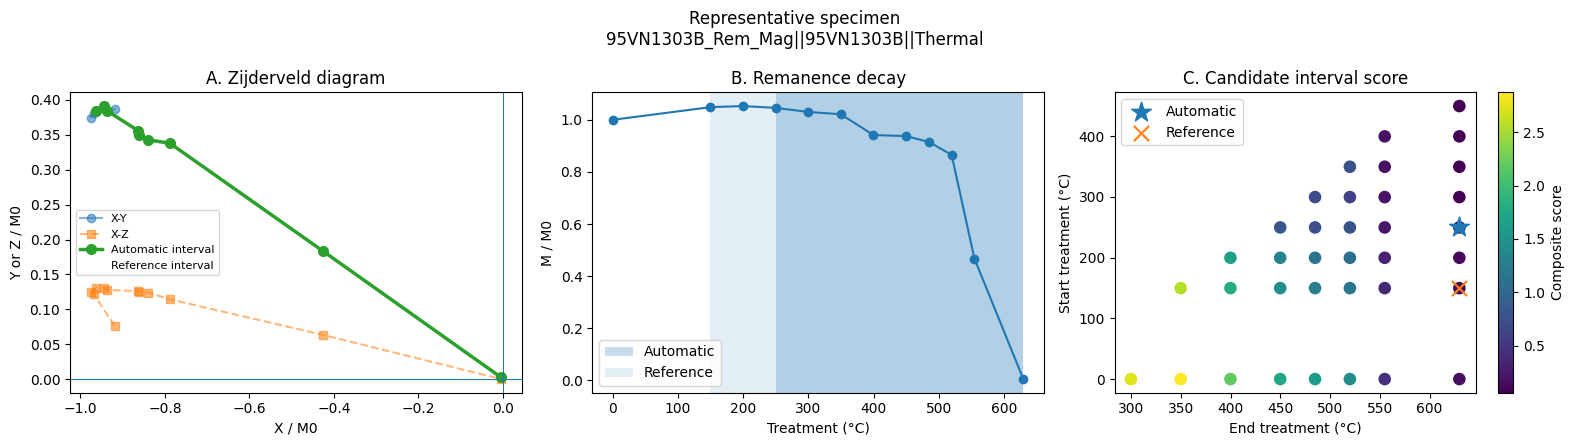

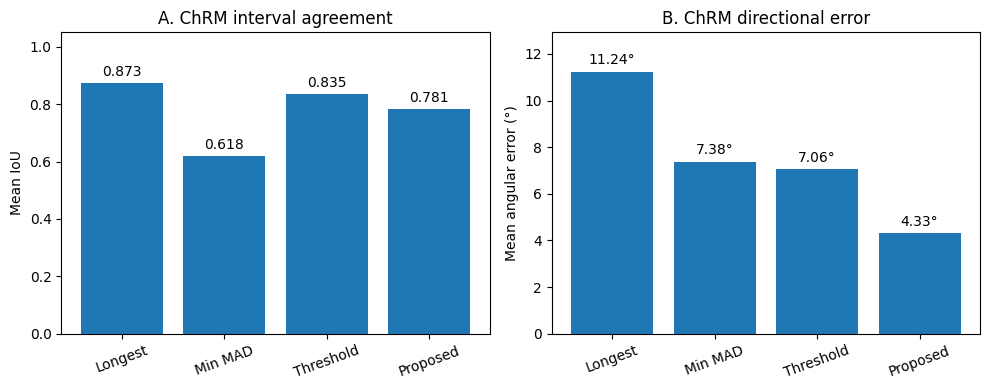

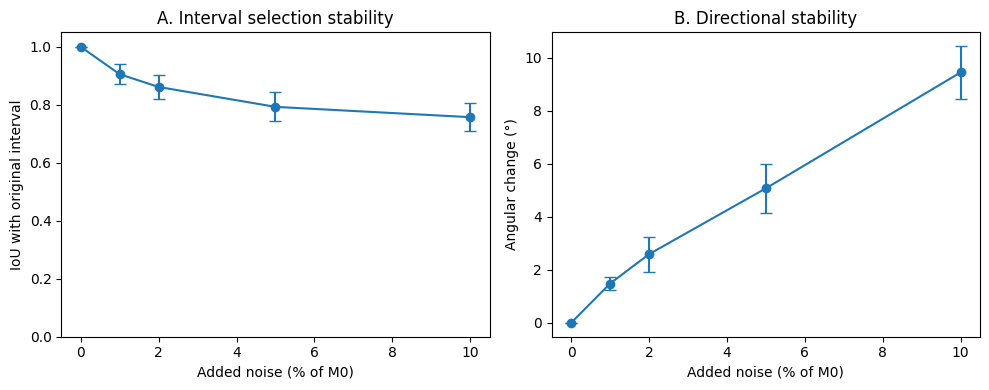

Noise specimens: 30
Repeats per noise level: 20

Noise robustness summary


,noise,mean_iou,std_iou,mean_angle,std_angle,n,ci95_iou,ci95_angle
0,0,1.000000,0.000000,0.000000,0.000000,30,0.000000,0.000000
1,1,0.905408,0.094301,1.482391,0.702653,30,0.033745,0.251441
2,2,0.861534,0.117907,2.592253,1.827354,30,0.042193,0.653910
3,5,0.792913,0.140572,5.077941,2.551308,30,0.050303,0.912974
4,10,0.757393,0.132403,9.453593,2.774042,30,0.047380,0.992678



결과 저장 위치: /content/chrm_result


In [ ]:
# ============================================================
# Figure 1. 대표 specimen의 자동 ChRM 선택
# ============================================================

proposed_eval = evaluation[evaluation["method"] == "Proposed"].copy()
median_iou = proposed_eval["iou"].median()

example_idx = (proposed_eval["iou"] - median_iou).abs().idxmin()
example_id = proposed_eval.loc[example_idx, "sequence_id"]

seq = sequences[example_id].reset_index(drop=True)
c = candidate_tables[example_id].copy()

c["score"] = c[FEATURES].values @ BEST_WEIGHTS
pred = select_proposed(c, BEST_WEIGHTS)

ref = reference_info[example_id]

s, e = int(pred["start_idx"]), int(pred["end_idx"])
ri, rj = ref["start_idx"], ref["end_idx"]

X = seq[["x", "y", "z"]].values / seq["mag"].iloc[0]
unit = seq["unit"].iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))


# ------------------------------------------------------------
# A. Zijderveld diagram
# ------------------------------------------------------------

axes[0].plot(X[:, 0], X[:, 1], "o-", alpha=0.55, label="X-Y")
axes[0].plot(X[:, 0], X[:, 2], "s--", alpha=0.55, label="X-Z")

# 자동 선택 구간 강조
axes[0].plot(
    X[s:e+1, 0], X[s:e+1, 1],
    "o-", linewidth=2.5, markersize=7,
    label="Automatic interval"
)

# Reference 구간은 빈 원으로 표시
axes[0].scatter(
    X[ri:rj+1, 0], X[ri:rj+1, 1],
    facecolors="none", s=100, linewidths=1.5,
    label="Reference interval"
)

axes[0].axhline(0, linewidth=0.7)
axes[0].axvline(0, linewidth=0.7)

axes[0].set_xlabel("X / M0")
axes[0].set_ylabel("Y or Z / M0")
axes[0].set_title("A. Zijderveld diagram")
axes[0].legend(fontsize=8)


# ------------------------------------------------------------
# B. Remanence decay
# ------------------------------------------------------------

axes[1].plot(seq["step"], seq["mag"] / seq["mag"].iloc[0], "o-")

axes[1].axvspan(
    seq["step"].iloc[s], seq["step"].iloc[e],
    alpha=0.25, label="Automatic"
)

axes[1].axvspan(
    seq["step"].iloc[ri], seq["step"].iloc[rj],
    alpha=0.12, label="Reference"
)

axes[1].set_xlabel(f"Treatment ({unit})")
axes[1].set_ylabel("M / M0")
axes[1].set_title("B. Remanence decay")
axes[1].legend()


# ------------------------------------------------------------
# C. Candidate score
# index 대신 실제 treatment 값 사용
# ------------------------------------------------------------

sc = axes[2].scatter(
    c["end_step"], c["start_step"],
    c=c["score"], s=65
)

axes[2].scatter(
    pred["end_step"], pred["start_step"],
    marker="*", s=220, label="Automatic"
)

axes[2].scatter(
    seq["step"].iloc[rj], seq["step"].iloc[ri],
    marker="x", s=120, label="Reference"
)

axes[2].set_xlabel(f"End treatment ({unit})")
axes[2].set_ylabel(f"Start treatment ({unit})")
axes[2].set_title("C. Candidate interval score")
axes[2].legend()

plt.colorbar(sc, ax=axes[2], label="Composite score")

plt.suptitle(f"Representative specimen\n{example_id}")
plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "Figure1_ChRM_selection.png"),
    dpi=250
)

plt.show()


# ============================================================
# Figure 2. 알고리즘 성능 비교
# ============================================================

labels = method_summary["method"].astype(str).tolist()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))


# ------------------------------------------------------------
# A. Mean IoU
# ------------------------------------------------------------

bars1 = axes[0].bar(labels, method_summary["mean_iou"])

axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Mean IoU")
axes[0].set_title("A. ChRM interval agreement")

axes[0].bar_label(
    bars1,
    labels=[f"{v:.3f}" for v in method_summary["mean_iou"]],
    padding=3
)


# ------------------------------------------------------------
# B. Mean angular error
# ------------------------------------------------------------

bars2 = axes[1].bar(labels, method_summary["mean_angle"])

axes[1].set_ylabel("Mean angular error (°)")
axes[1].set_title("B. ChRM directional error")

axes[1].set_ylim(
    0,
    method_summary["mean_angle"].max() * 1.15
)

axes[1].bar_label(
    bars2,
    labels=[f"{v:.2f}°" for v in method_summary["mean_angle"]],
    padding=3
)


for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "Figure2_method_comparison.png"),
    dpi=250
)

plt.show()


# ============================================================
# Figure 3. 노이즈 강건성
# ============================================================

NOISE_LEVELS = [0, 1, 2, 5, 10]

# 기존 10개 × 10회 → 30개 × 20회
NOISE_SPECIMENS = min(30, len(test_ids))
REPEATS = 20

# 노이즈 실험용 난수는 별도로 고정
noise_rng = np.random.default_rng(SEED + 100)

noise_ids = noise_rng.choice(
    np.array(test_ids),
    size=NOISE_SPECIMENS,
    replace=False
)

noise_rows = []


for sid in noise_ids:
    original = sequences[sid].copy()
    original_pred = select_proposed(candidate_tables[sid], BEST_WEIGHTS)

    original_vector = dir2cart(
        original_pred["dec"],
        original_pred["inc"],
        1
    )

    X0 = original[["x", "y", "z"]].values
    M0 = original["mag"].iloc[0]

    for noise_level in NOISE_LEVELS:
        for repeat in range(REPEATS):

            noisy = original.copy()

            noise = noise_rng.normal(
                0,
                noise_level / 100 * M0,
                X0.shape
            )

            X_noisy = X0 + noise

            noisy[["x", "y", "z"]] = X_noisy
            noisy["mag"] = np.linalg.norm(X_noisy, axis=1)

            candidates_noise = make_candidates(noisy)
            pred = select_proposed(candidates_noise, BEST_WEIGHTS)

            pred_vector = dir2cart(pred["dec"], pred["inc"], 1)

            noise_rows.append({
                "sequence_id": sid,
                "noise": noise_level,
                "repeat": repeat,

                "interval_iou": interval_iou(
                    original_pred["start_idx"],
                    original_pred["end_idx"],
                    pred["start_idx"],
                    pred["end_idx"]
                ),

                "angular_change": vector_angle(
                    original_vector,
                    pred_vector
                )
            })


noise_results = pd.DataFrame(noise_rows)


# ============================================================
# 반복 측정값을 먼저 specimen별로 평균
# → 특정 specimen의 반복 횟수가 통계를 과도하게 지배하지 않도록 함
# ============================================================

noise_by_specimen = (
    noise_results
    .groupby(["sequence_id", "noise"])
    .agg(
        interval_iou=("interval_iou", "mean"),
        angular_change=("angular_change", "mean")
    )
    .reset_index()
)


# ============================================================
# specimen 간 평균, 표준편차, 95% CI 계산
# ============================================================

noise_summary = (
    noise_by_specimen
    .groupby("noise")
    .agg(
        mean_iou=("interval_iou", "mean"),
        std_iou=("interval_iou", "std"),

        mean_angle=("angular_change", "mean"),
        std_angle=("angular_change", "std"),

        n=("sequence_id", "nunique")
    )
    .reset_index()
)

noise_summary["ci95_iou"] = (
    1.96 * noise_summary["std_iou"] / np.sqrt(noise_summary["n"])
)

noise_summary["ci95_angle"] = (
    1.96 * noise_summary["std_angle"] / np.sqrt(noise_summary["n"])
)


# ============================================================
# Figure 3
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))


# ------------------------------------------------------------
# A. 구간 선택 안정성
# ------------------------------------------------------------

axes[0].errorbar(
    noise_summary["noise"],
    noise_summary["mean_iou"],
    yerr=noise_summary["ci95_iou"],
    marker="o",
    capsize=4
)

axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel("Added noise (% of M0)")
axes[0].set_ylabel("IoU with original interval")
axes[0].set_title("A. Interval selection stability")


# ------------------------------------------------------------
# B. 방향 안정성
# ------------------------------------------------------------

axes[1].errorbar(
    noise_summary["noise"],
    noise_summary["mean_angle"],
    yerr=noise_summary["ci95_angle"],
    marker="o",
    capsize=4
)

axes[1].set_xlabel("Added noise (% of M0)")
axes[1].set_ylabel("Angular change (°)")
axes[1].set_title("B. Directional stability")


plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "Figure3_noise_robustness.png"),
    dpi=250
)

plt.show()


# ============================================================
# 결과 저장
# ============================================================

noise_results.to_csv(
    os.path.join(OUT_DIR, "noise_results_raw.csv"),
    index=False
)

noise_by_specimen.to_csv(
    os.path.join(OUT_DIR, "noise_results_by_specimen.csv"),
    index=False
)

noise_summary.to_csv(
    os.path.join(OUT_DIR, "noise_summary.csv"),
    index=False
)

print("Noise specimens:", NOISE_SPECIMENS)
print("Repeats per noise level:", REPEATS)

print("\nNoise robustness summary")
display(noise_summary)

print("\n결과 저장 위치:", OUT_DIR)